In [1]:
# Cell 1 — Install dependencies
%pip install pandas numpy seaborn matplotlib scikit-learn wordcloud nltk -q


Note: you may need to restart the kernel to use updated packages.


In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
reviews_amz = pd.read_csv('Beginner_Reviews_dataset.csv')

In [4]:
reviews_amz

,Unnamed: 0,sentence,label
0,0,Wow... Loved this place.,1
1,1,Crust is not good.,0
2,2,Not tasty and the texture was just nasty.,0
3,3,Stopped by during the late May bank holiday of...,1
4,4,The selection on the menu was great and so wer...,1
...,...,...,...
995,995,I think food should have flavor and texture an...,0
996,996,Appetite instantly gone.,0
997,997,Overall I was not impressed and would not go b...,0
998,998,"The whole experience was underwhelming, and I ...",0


In [5]:
reviews_amz['sentence']

0                               Wow... Loved this place.
1                                     Crust is not good.
2              Not tasty and the texture was just nasty.
3      Stopped by during the late May bank holiday of...
4      The selection on the menu was great and so wer...
                             ...                        
995    I think food should have flavor and texture an...
996                             Appetite instantly gone.
997    Overall I was not impressed and would not go b...
998    The whole experience was underwhelming, and I ...
999    Then, as if I hadn't wasted enough of my life ...
Name: sentence, Length: 1000, dtype: object

In [6]:
reviews_amz.head()


,Unnamed: 0,sentence,label
0,0,Wow... Loved this place.,1
1,1,Crust is not good.,0
2,2,Not tasty and the texture was just nasty.,0
3,3,Stopped by during the late May bank holiday of...,1
4,4,The selection on the menu was great and so wer...,1


In [7]:
print(reviews_amz.columns)


Index(['Unnamed: 0', 'sentence', 'label'], dtype='object')


In [8]:
reviews_amz = reviews_amz.drop(['Unnamed: 0'], axis=1)

<Axes: >

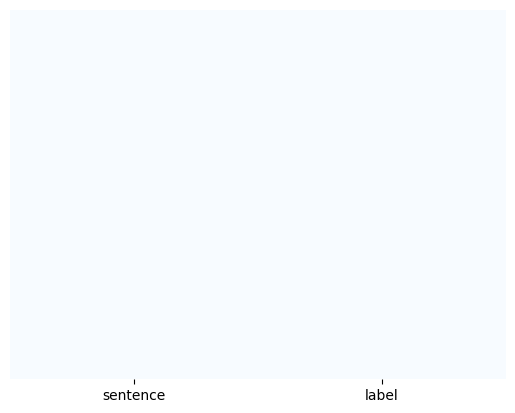

In [9]:
sns.heatmap(reviews_amz.isnull(), yticklabels=False, cbar =False , cmap="Blues")

array([[<Axes: title={'center': 'label'}>]], dtype=object)

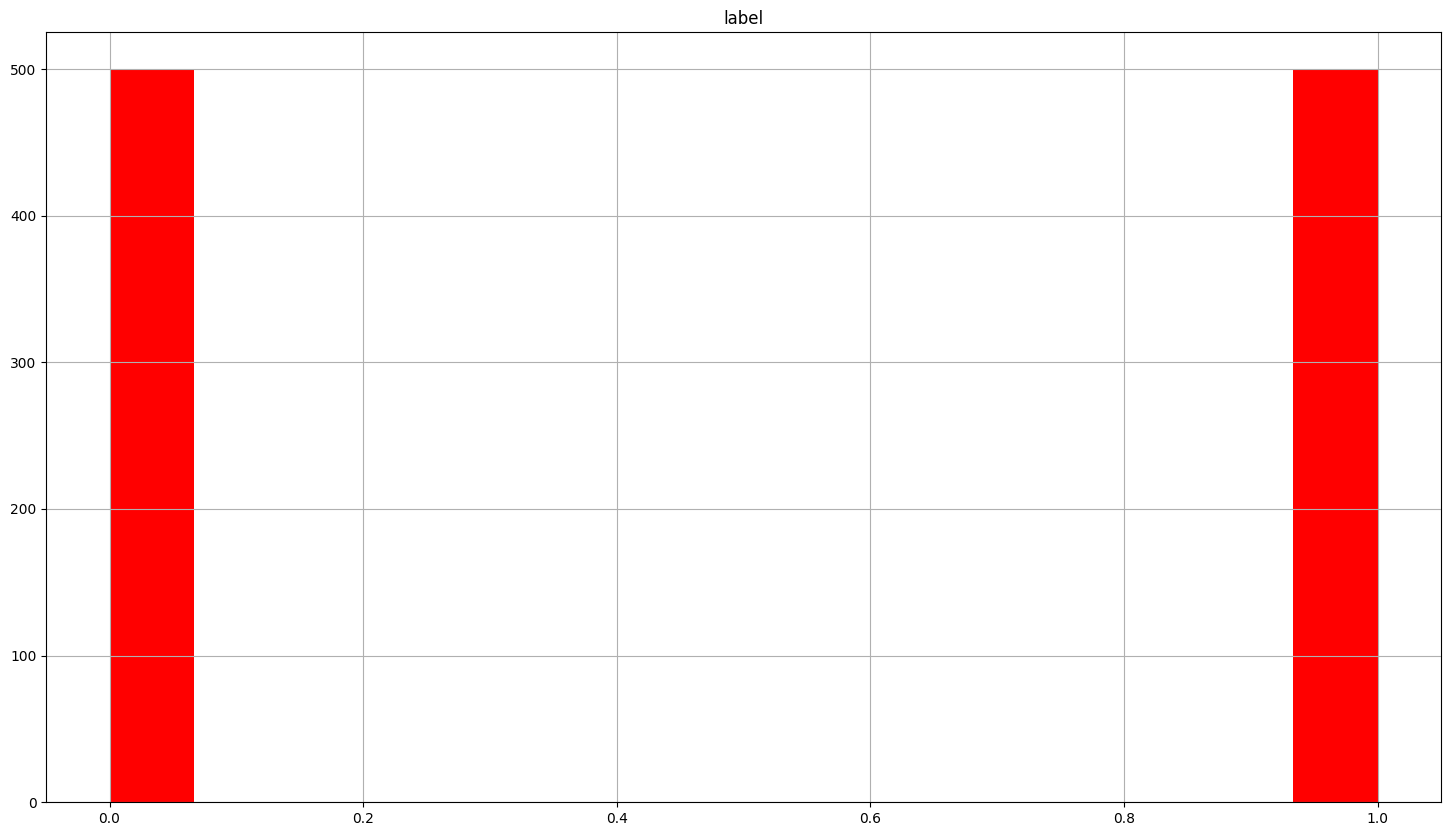

In [10]:
reviews_amz.hist(bins=15, figsize=(18,10), color='red')

<Axes: xlabel='label', ylabel='count'>

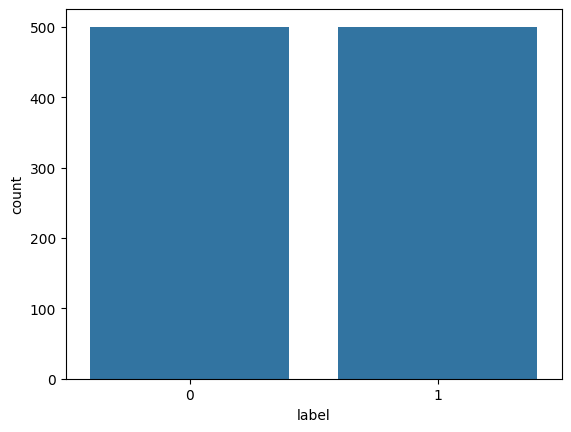

In [11]:
sns.countplot(x='label', data=reviews_amz)
# sns.countplot(reviews_amz['rating'], label = 'count')


In [12]:
# Fill NaN with empty string
reviews_amz['sentence'] = reviews_amz['sentence'].fillna('')
# if you want to drop all null rows
# reviews_amz = reviews_amz[reviews_amz['sentence'].notnull()]

In [13]:
reviews_amz['length'] = reviews_amz['sentence'].astype(str).apply(len) #it will only take that which are string and drop that
reviews_amz

,sentence,label,length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59
...,...,...,...
995,I think food should have flavor and texture an...,0,66
996,Appetite instantly gone.,0,24
997,Overall I was not impressed and would not go b...,0,50
998,"The whole experience was underwhelming, and I ...",0,91


In [14]:
reviews_amz[reviews_amz['length'] == 12]['sentence']

114    Good prices.
562    A good time!
Name: sentence, dtype: object

In [15]:
reviews_amz[reviews_amz['length'] == 85]['sentence'].iloc[0]
#intergral location like indexing

'My husband and I ate lunch here and were very disappointed with the food and service.'

<Axes: title={'center': 'Distribution of Review Lengths'}, ylabel='Frequency'>

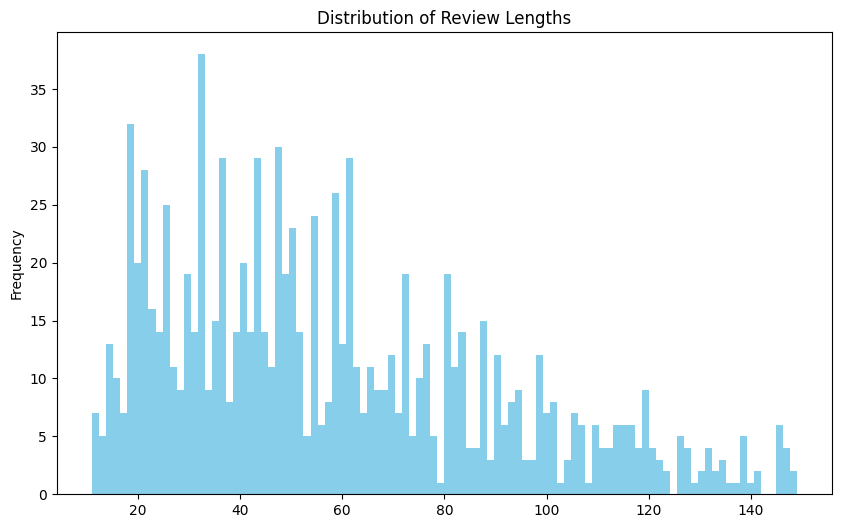

In [16]:
reviews_amz['length'].plot(kind='hist', bins=100, figsize=(10, 6), color='skyblue', title='Distribution of Review Lengths')


In [17]:
positive = reviews_amz[reviews_amz['label']==1]
positive

,sentence,label,length
0,Wow... Loved this place.,1,24
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59
8,The fries were great too.,1,25
9,A great touch.,1,14
...,...,...,...
899,"Overall, a great experience.",1,28
901,Their regular toasted bread was equally satisf...,1,97
907,The chips and sals a here is amazing!!!!!!!!!!...,1,55
909,This is my new fav Vegas buffet spot.,1,37


In [18]:
negative = reviews_amz[reviews_amz['label']==0]
negative

,sentence,label,length
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
5,Now I am getting angry and I want my damn pho.,0,46
6,Honeslty it didn't taste THAT fresh.),0,37
7,The potatoes were like rubber and you could te...,0,111
...,...,...,...
995,I think food should have flavor and texture an...,0,66
996,Appetite instantly gone.,0,24
997,Overall I was not impressed and would not go b...,0,50
998,"The whole experience was underwhelming, and I ...",0,91


In [19]:
#to combine all the tweets
sentences = reviews_amz['sentence'].tolist()
len(sentences)

1000

In [20]:
sentences_to_string = " ".join(sentences)
sentences_to_string

'Wow... Loved this place. Crust is not good. Not tasty and the texture was just nasty. Stopped by during the late May bank holiday off Rick Steve recommendation and loved it. The selection on the menu was great and so were the prices. Now I am getting angry and I want my damn pho. Honeslty it didn\'t taste THAT fresh.) The potatoes were like rubber and you could tell they had been made up ahead of time being kept under a warmer. The fries were great too. A great touch. Service was very prompt. Would not go back. The cashier had no care what so ever on what I had to say it still ended up being wayyy overpriced. I tried the Cape Cod ravoli, chicken,with cranberry...mmmm! I was disgusted because I was pretty sure that was human hair. I was shocked because no signs indicate cash only. Highly recommended. Waitress was a little slow in service. This place is not worth your time, let alone Vegas. did not like at all. The Burrittos Blah! The food, amazing. Service is also cute. I could care le

In [21]:
from wordcloud import wordcloud

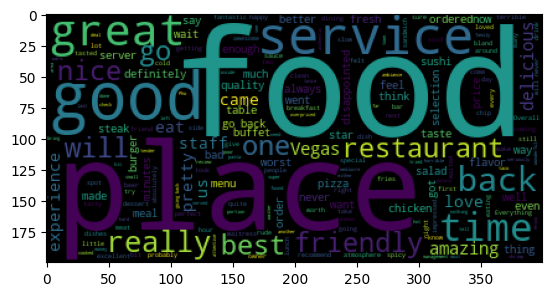

In [22]:
from wordcloud import WordCloud
# plt.figure(figsize=(20,20))
plt.imshow(WordCloud().generate(sentences_to_string))

In [23]:
#perform data cleanning

In [24]:
import string
string.punctuation
test = "@I love my india do you!!"
test_puch_remove = [char for char in test if char not in string.punctuation]
test_puch_remove_join = " ".join(test_puch_remove)
test_puch_remove_join

'I   l o v e   m y   i n d i a   d o   y o u'

In [25]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arnav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [27]:
test_puch_remove_join2 = 'I am enjoying coding, programing'
test_puch_remove_join2_clean = [
    word for word in test_puch_remove_join2.split()
    if word.lower() not in stopwords.words('english')
]

print(test_puch_remove_join2_clean)

['enjoying', 'coding,', 'programing']


In [28]:
import string
string.punctuation
sentences_puch_remove = [char for char in sentences_to_string if char not in string.punctuation]
sentences_puch_remove_join = "".join(sentences_puch_remove)
sentences_puch_remove_join

'Wow Loved this place Crust is not good Not tasty and the texture was just nasty Stopped by during the late May bank holiday off Rick Steve recommendation and loved it The selection on the menu was great and so were the prices Now I am getting angry and I want my damn pho Honeslty it didnt taste THAT fresh The potatoes were like rubber and you could tell they had been made up ahead of time being kept under a warmer The fries were great too A great touch Service was very prompt Would not go back The cashier had no care what so ever on what I had to say it still ended up being wayyy overpriced I tried the Cape Cod ravoli chickenwith cranberrymmmm I was disgusted because I was pretty sure that was human hair I was shocked because no signs indicate cash only Highly recommended Waitress was a little slow in service This place is not worth your time let alone Vegas did not like at all The Burrittos Blah The food amazing Service is also cute I could care less The interior is just beautiful So

In [29]:
sentences_to_string_clean = [
    word for word in sentences_puch_remove_join.split()
    if word.lower() not in stopwords.words('english')
]

print(sentences_to_string_clean)

['Wow', 'Loved', 'place', 'Crust', 'good', 'tasty', 'texture', 'nasty', 'Stopped', 'late', 'May', 'bank', 'holiday', 'Rick', 'Steve', 'recommendation', 'loved', 'selection', 'menu', 'great', 'prices', 'getting', 'angry', 'want', 'damn', 'pho', 'Honeslty', 'didnt', 'taste', 'fresh', 'potatoes', 'like', 'rubber', 'could', 'tell', 'made', 'ahead', 'time', 'kept', 'warmer', 'fries', 'great', 'great', 'touch', 'Service', 'prompt', 'Would', 'go', 'back', 'cashier', 'care', 'ever', 'say', 'still', 'ended', 'wayyy', 'overpriced', 'tried', 'Cape', 'Cod', 'ravoli', 'chickenwith', 'cranberrymmmm', 'disgusted', 'pretty', 'sure', 'human', 'hair', 'shocked', 'signs', 'indicate', 'cash', 'Highly', 'recommended', 'Waitress', 'little', 'slow', 'service', 'place', 'worth', 'time', 'let', 'alone', 'Vegas', 'like', 'Burrittos', 'Blah', 'food', 'amazing', 'Service', 'also', 'cute', 'could', 'care', 'less', 'interior', 'beautiful', 'performed', 'Thats', 'rightthe', 'red', 'velvet', 'cakeohhh', 'stuff', 'goo

In [30]:
# back to nltk
reviews_amz

,sentence,label,length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59
...,...,...,...
995,I think food should have flavor and texture an...,0,66
996,Appetite instantly gone.,0,24
997,Overall I was not impressed and would not go b...,0,50
998,"The whole experience was underwhelming, and I ...",0,91


In [31]:
# reviews_amz['label'] = (reviews_amz['overall'] >= 3).astype(int)
# reviews_amz

In [32]:
import re
import string

# remove punctuation
def removepunctuation(sentence):
    return ''.join(char for char in sentence if char not in string.punctuation)

# Apply it to each row in the 'sentence' column and create a new column
reviews_amz['clean_review'] = reviews_amz['sentence'].apply(removepunctuation)
reviews_amz


,sentence,label,length,clean_review
0,Wow... Loved this place.,1,24,Wow Loved this place
1,Crust is not good.,0,18,Crust is not good
2,Not tasty and the texture was just nasty.,0,41,Not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,87,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...,1,59,The selection on the menu was great and so wer...
...,...,...,...,...
995,I think food should have flavor and texture an...,0,66,I think food should have flavor and texture an...
996,Appetite instantly gone.,0,24,Appetite instantly gone
997,Overall I was not impressed and would not go b...,0,50,Overall I was not impressed and would not go back
998,"The whole experience was underwhelming, and I ...",0,91,The whole experience was underwhelming and I t...


In [33]:
def clean_text(sentence):
    sentence = sentence.lower()
    return ''.join(char for char in sentence if char not in string.punctuation)

reviews_amz['clean_review'] = reviews_amz['sentence'].apply(clean_text)
reviews_amz


,sentence,label,length,clean_review
0,Wow... Loved this place.,1,24,wow loved this place
1,Crust is not good.,0,18,crust is not good
2,Not tasty and the texture was just nasty.,0,41,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,87,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,59,the selection on the menu was great and so wer...
...,...,...,...,...
995,I think food should have flavor and texture an...,0,66,i think food should have flavor and texture an...
996,Appetite instantly gone.,0,24,appetite instantly gone
997,Overall I was not impressed and would not go b...,0,50,overall i was not impressed and would not go back
998,"The whole experience was underwhelming, and I ...",0,91,the whole experience was underwhelming and i t...


In [34]:
stop_words = set(stopwords.words('english'))

def stop_words_clean(sentence):
    sentence = sentence.lower()
    sentence = ''.join(char for char in sentence if char not in string.punctuation)
    words = [word for word in sentence.split() if word not in stop_words]
    words = ' '.join(words)
    return words

cleaned_reviews = [stop_words_clean(doc) for doc in reviews_amz['sentence']]
reviews_amz['clean_review'] = cleaned_reviews
reviews_amz.head()


,sentence,label,length,clean_review
0,Wow... Loved this place.,1,24,wow loved place
1,Crust is not good.,0,18,crust good
2,Not tasty and the texture was just nasty.,0,41,tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,87,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,59,selection menu great prices


x = data['text']
y = data['label']

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
bow_transformer = CountVectorizer(analyzer= stop_words_clean).fit(reviews_amz['clean_review'])


In [36]:
# Then your features and target:
X = bow_transformer.transform(reviews_amz['clean_review'])  # numeric feature matrix
y = reviews_amz['label']  # numeric target labels

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(class_weight='balanced')  # Add this argument
classifier.fit(X_train, y_train)
Y_pred = classifier.predict(X_test)


c:\Users\arnav\Documents\sentiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, Y_pred))
print(classification_report(y_test, Y_pred))


[[59 37]
 [37 67]]
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        96
           1       0.64      0.64      0.64       104

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200



In [40]:
# Ensure scikit-learn is installed (required when the editor/linter flags the import)
%pip install scikit-learn -q

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, Y_pred)
print('Accuracy of the model:', acc)

Note: you may need to restart the kernel to use updated packages.
Accuracy of the model: 0.63


In [41]:
print(classifier.predict(bow_transformer.transform(['waste of money'])))

[0]


In [42]:
print(classifier.predict(bow_transformer.transform(['place was good,loved it'])))

[1]


In [43]:
print(classifier.predict(bow_transformer.transform([' bad'])))

[0]


In [44]:
print(classifier.predict(bow_transformer.transform(['card was bad,dislike it'])))

[0]


In [45]:
test_text = 'card was bad, dislike it'
cleaned_test_text = stop_words_clean(test_text)  # Your cleaning function
prediction = classifier.predict(bow_transformer.transform([cleaned_test_text]))
print(prediction)


[0]


In [46]:
print(reviews_amz['label'].value_counts())


label
1    500
0    500
Name: count, dtype: int64


In [47]:
probs = classifier.predict_proba(bow_transformer.transform(['card was bad, dislike it']))[:,1]
print(probs)  # Probability of label 1
pred = 1 if probs > 0.7 else 0
print(pred)


[0.2891529]
0


In [48]:
print(classifier.predict(bow_transformer.transform(['i love this food'])))


[1]


In [49]:
print(classifier.predict(bow_transformer.transform(['i dislike this food'])))


[0]


In [50]:
print(classifier.predict(bow_transformer.transform(['we went to bhopal that was average place'])))

[1]


In [51]:
print (classifier .predict(bow_transformer.transform(['i am happy'])))

[1]
